# Predstavitev dobljenih podatkov

In [275]:
import pandas as pd
import matplotlib.pyplot as plt

### Uvoz podatkov iz obeh csv datotek.

In [276]:
podatki_serije = pd.read_csv("shows/shows_community.csv")
podatki_epizode = pd.read_csv("shows/epizode_community.csv")

In [277]:
podatki_serije

,Naslov,Povprecna_ocena_epizode,Stevilo_epizod,Stevilo_ocen_epizod,Stevilo_ocen_serije,Povprecna_ocena_serije,Minimalna_ocena,Maksimalna_ocena,Pozicija,ID,Prva_epizoda,Najnovejša_epizoda,Povprecna_dolzina_epizode,Stevilo_sezon
0,Breaking Bad,8.94,62,4536709,2650561.0,9.5,7.9,9.8,1,1396,2008-01-20,2013-09-29,48.31,5
1,Attack on Titan,9.12,89,4308546,734040.0,9.1,8.1,9.8,2,1429,2013-04-07,2022-04-04,23.99,4
2,Game of Thrones,8.74,73,5940939,2641552.0,9.2,4.0,9.9,3,1399,2011-04-17,2019-05-19,57.97,8
3,The Sopranos,8.61,86,925281,588505.0,9.2,7.7,9.7,4,1398,1999-01-10,2007-06-10,54.14,6
4,Avatar: The Last Airbender,8.60,61,534820,450109.0,9.3,6.8,9.9,5,246,2005-02-21,2008-07-19,24.66,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,Hacks,8.30,47,71725,68059.0,8.2,7.6,9.5,246,124101,2021-05-13,2026-05-28,33.55,5
243,Hell on Wheels,8.22,57,43111,60094.0,8.3,7.3,8.9,247,1401,2011-11-06,2015-08-08,28.04,5
244,Derry Girls,8.19,19,31827,78757.0,8.5,7.6,9.1,248,76148,2018-01-04,2022-05-18,25.47,3
245,Justice League,8.05,52,55300,57602.0,8.5,7.3,9.3,249,1618,2001-11-17,2004-05-29,24.96,2


In [278]:
podatki_epizode 

,vote_average,community_count,episode_number,season_number,air_date,runtime,id,pozicija,stevilo_epizod,ocena_serije
0,9.0,12576,1,1,2008-01-20,59,1396,1,62,9.5
1,8.7,12033,2,1,2008-01-27,49,1396,1,62,9.5
2,8.8,11887,3,1,2008-02-10,49,1396,1,62,9.5
3,8.5,11768,4,1,2008-02-17,49,1396,1,62,9.5
4,8.3,11674,5,1,2008-02-24,49,1396,1,62,9.5
...,...,...,...,...,...,...,...,...,...,...
22084,8.4,9,34,5,2025-11-15,11,1877,250,150,8.1
22085,8.0,9,35,5,2025-11-15,11,1877,250,150,8.1
22086,8.4,9,36,5,2026-01-16,11,1877,250,150,8.1
22087,8.2,9,37,5,2026-01-16,11,1877,250,150,8.1


### Ali dolžina epizode vpliva na oceno epizode oziroma katera dolžina je najbolj priljubljena?

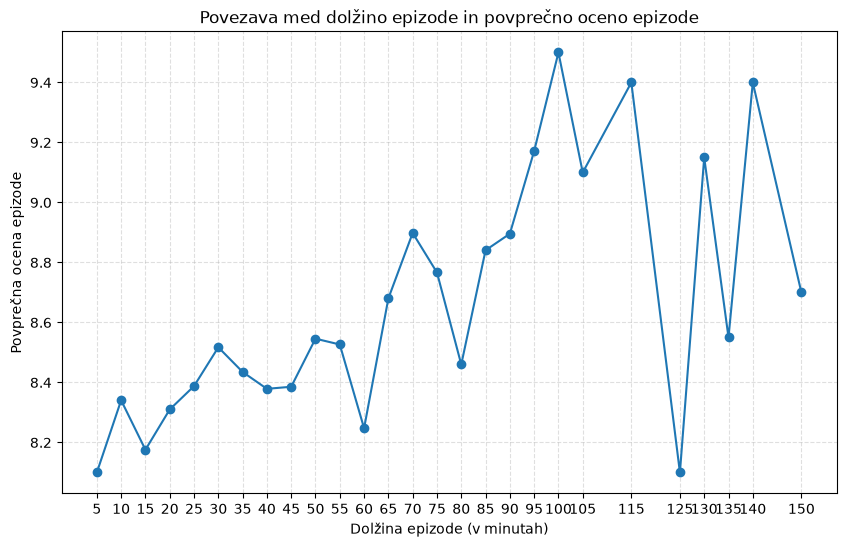

In [279]:
podatki_epizode["bins_dolzina"] = (podatki_epizode["runtime"] // 5) * 5

intervali = (
    podatki_epizode.groupby("bins_dolzina")["vote_average"]
    .mean()
    .sort_index()
)
plt.figure(figsize=(10, 6))
plt.title("Povezava med dolžino epizode in povprečno oceno epizode")
plt.xlabel("Dolžina epizode (v minutah)")
plt.ylabel("Povprečna ocena epizode")
plt.plot(intervali.index, intervali.values, marker="o")
plt.xticks(intervali.index)
plt.grid(True, linestyle="--", alpha=0.4)


Iz grafa je razvidno, da so v povprečju najboljše ocenjene epizode dolge približno 100 minut.

### Katera dolžina epizode pa je najpogostejša?

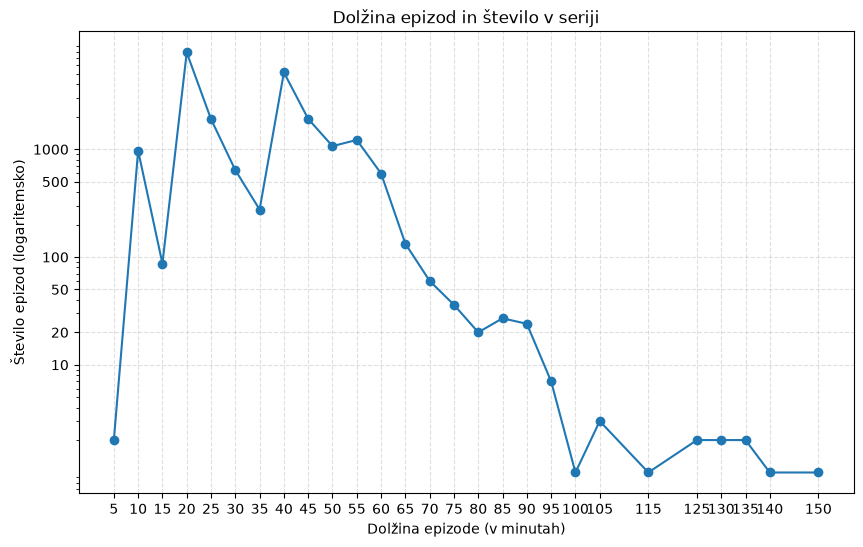

In [280]:
podatki_epizode["bins_dolzina"] = (podatki_epizode["runtime"] // 5) * 5

intervali = (
    podatki_epizode.groupby("bins_dolzina")["vote_average"]
    .count()
    .sort_index()
)

ticks = [10, 20, 50, 100, 500, 1000]
labels = [str(t) for t in ticks]

plt.figure(figsize=(10, 6))
plt.title("Dolžina epizod in število v seriji")
plt.xlabel("Dolžina epizode (v minutah)")
plt.ylabel("Število epizod (logaritemsko)")
plt.plot(intervali.index, intervali.values, marker="o")
plt.xticks(intervali.index)
plt.yscale("log")
plt.yticks(ticks, labels)
plt.grid(True, linestyle="--", alpha=0.4)


Iz grafa je razvidno, da je najpogostejša dolžina epizode približno 20 minut. Da so razvidne tudi razlike med manj pogostimi dolžinami, sem na grafu y-os spremenila v logaritemsko. 

### Bi bil vrstni red seznama drugačen, če bi primerjali po povprečni oceni epizode in ne po oceni serije?

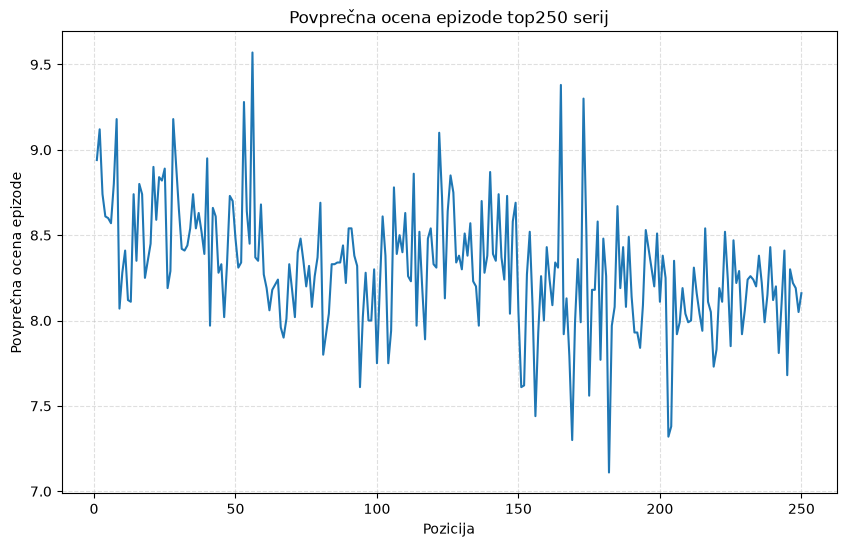

In [281]:
plt.figure(figsize=(10, 6))
plt.title("Povprečna ocena epizode top250 serij")
plt.xlabel("Pozicija")
plt.ylabel("Povprečna ocena epizode")
plt.plot(podatki_serije["Pozicija"], podatki_serije["Povprecna_ocena_epizode"])
plt.grid(True, linestyle="--", alpha=0.4)

### Kateri mesec je bilo izdanih največ epizod?

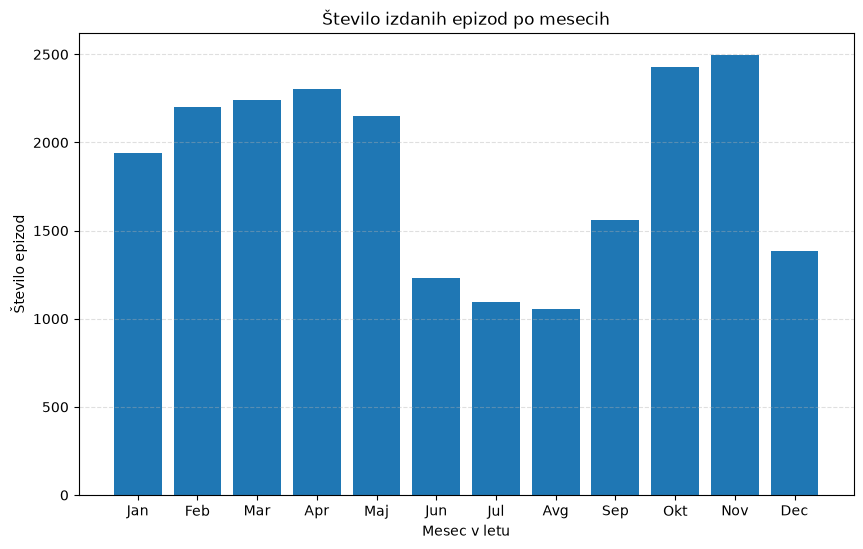

In [282]:
podatki_epizode["mesec"] = pd.to_datetime(podatki_epizode["air_date"]).dt.month
mesec_stats = (
    podatki_epizode.groupby("mesec", as_index=False)
    .agg(stevilo_epizod=("vote_average", "size"), povprecna_ocena=("vote_average", "mean"))
    .sort_values("mesec")
)
mesec_stats["mesec_label"] = mesec_stats["mesec"].map({
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "Maj", 6: "Jun",
    7: "Jul", 8: "Avg", 9: "Sep", 10: "Okt", 11: "Nov", 12: "Dec"
})
plt.figure(figsize=(10,6))
plt.bar(mesec_stats["mesec_label"], mesec_stats["stevilo_epizod"])
plt.title("Število izdanih epizod po mesecih")
plt.xlabel("Mesec v letu")
plt.ylabel("Število epizod")
plt.grid(axis="y", linestyle="--", alpha=0.4)


Iz grafa je razvidno, da je največ epizod izdanih v novembru, najboljše pa so ocenjene epizode meseca junija in avgusta, ki sta med manj pogostimi meseci.

### Ali imajo boljše ocenjene serije tudi večje število ocen?

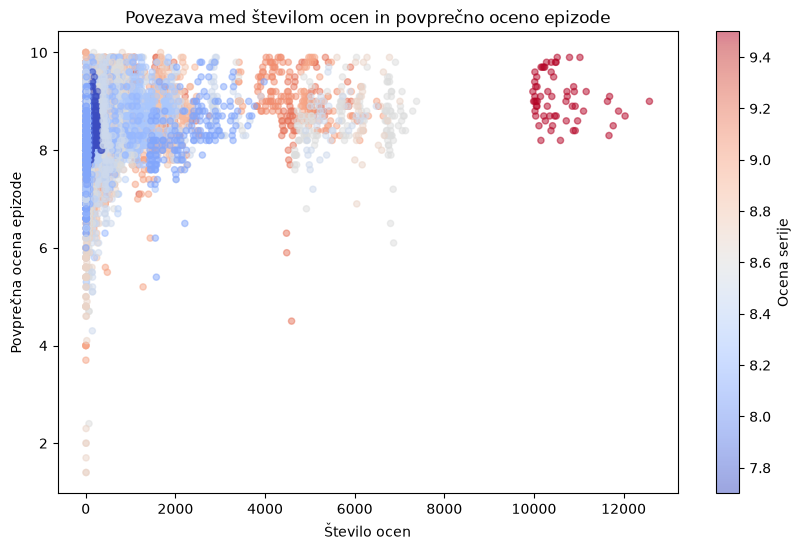

In [283]:
stevilo_ocen = podatki_epizode["community_count"]
povprecna_ocena = podatki_epizode["vote_average"]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(stevilo_ocen, povprecna_ocena, s=20, c=podatki_epizode["ocena_serije"], cmap="coolwarm",alpha=0.5)
plt.title("Povezava med številom ocen in povprečno oceno epizode")
plt.xlabel("Število ocen")  
plt.ylabel("Povprečna ocena epizode")
plt.colorbar(scatter, label="Ocena serije")

Moja hipoteza je bila, da bodo največkrat ocenjene epizode imele tudi eno izmed najboljših povprečnih ocen. Kasneje sem dodala še barvno skalo, s pomočjo katere je možno razbrati, da največrat ocenjene epizode vse pripadajo tudi najboljše ocenjenim serijam. 

### Kako dolgo so snemali vsako serijo na seznamu najboljše ocenjenih serij?

Text(0, 0.5, 'Trajanje serije (v letih)')

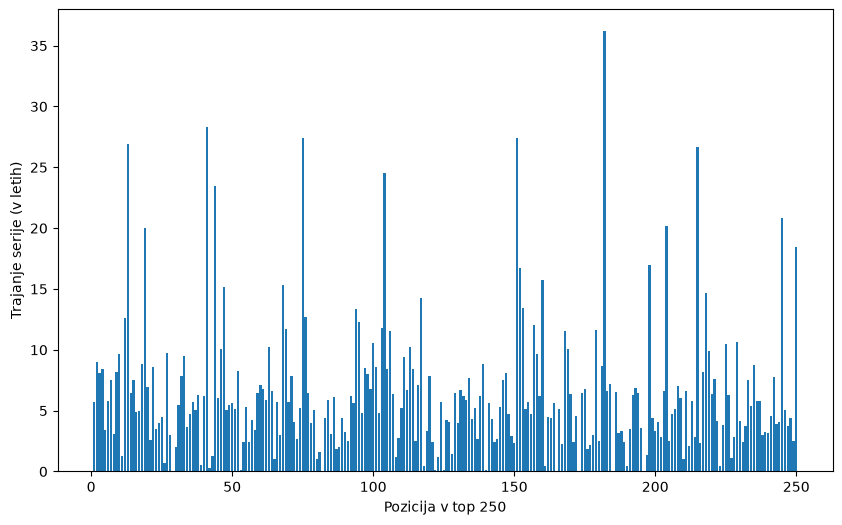

In [284]:
dolzina_snemanja = pd.to_datetime(podatki_serije["Najnovejša_epizoda"]) - pd.to_datetime(podatki_serije["Prva_epizoda"])
pozicija = podatki_serije["Pozicija"]
dolzina_snemanja = dolzina_snemanja.dt.days / 365.25
plt.figure(figsize=(10, 6))
plt.bar(pozicija, dolzina_snemanja)
plt.xlabel("Pozicija v top 250")  
plt.ylabel("Trajanje serije (v letih)")

S pomočjo tega grafa je najlepše razvidno, kako dolgo so snemali vsako izmed serij in da je večina teh bila posneta v manj kot desetih letih.

### Ali imajo serije z večjim številom epizod tudi večje razlike med ocenami po epizodah?

C:\Users\necak\AppData\Local\Temp\ipykernel_42012\865964062.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


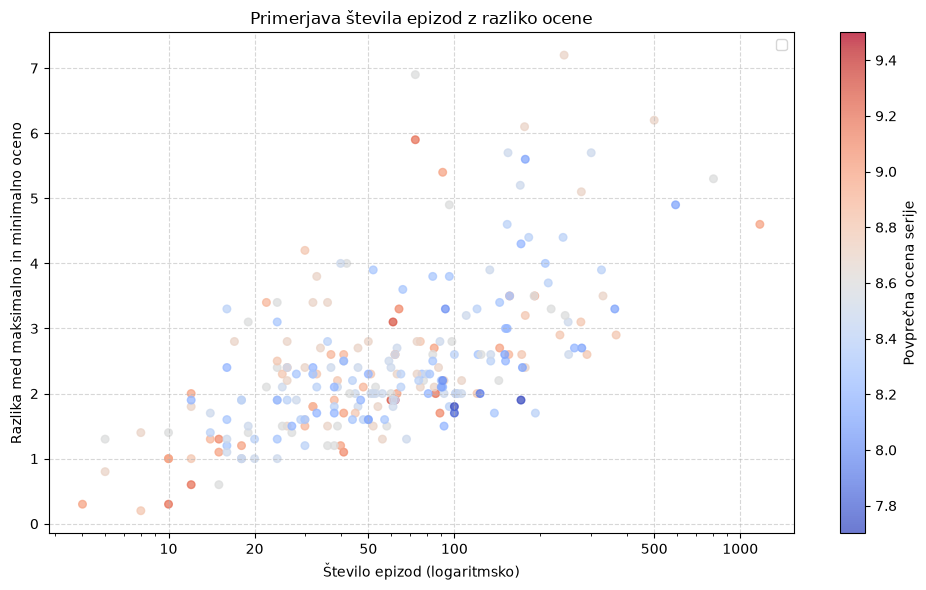

In [285]:
podatki_serije["Razlika_ocena"] = podatki_serije["Maksimalna_ocena"] - podatki_serije["Minimalna_ocena"]

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    podatki_serije["Stevilo_epizod"],
    podatki_serije["Razlika_ocena"],
    s=30,
    c=podatki_serije["Povprecna_ocena_serije"],
    cmap="coolwarm",
    alpha=0.75
)

ax.set_xscale("log")
ticks = [10, 20, 50, 100, 500, 1000]
ax.set_xticks(ticks)
ax.set_xticklabels([str(t) for t in ticks])

ax.set_title("Primerjava števila epizod z razliko ocene")
ax.set_xlabel("Število epizod (logaritmsko)")
ax.set_ylabel("Razlika med maksimalno in minimalno oceno")
ax.grid(True, linestyle="--", alpha=0.5)

fig.colorbar(scatter, ax=ax, label="Povprečna ocena serije")
ax.legend()
plt.tight_layout()
plt.show()


Da so rezultati bolj razivdni sem x-os preoblikovala v logaritemsko, prav tako sem dodala barvno skalo, ki prikazuje pozicijo serije na seznamu top250. Rezultati so večinoma v skladu z mojo hipotezo, da imajo večjo razliko med najboljše in najslabše ocenjeno epizodo serije z večjim številom epizod.

### Koliko izmed teh serij je "aktivnih"? 
V zadnjem grafu sem želela preveriti koliko izmed vseh serij je tako rečeno aktivnih, torej so v zadnjih dveh letih izdali vsaj eno novo epizodo.

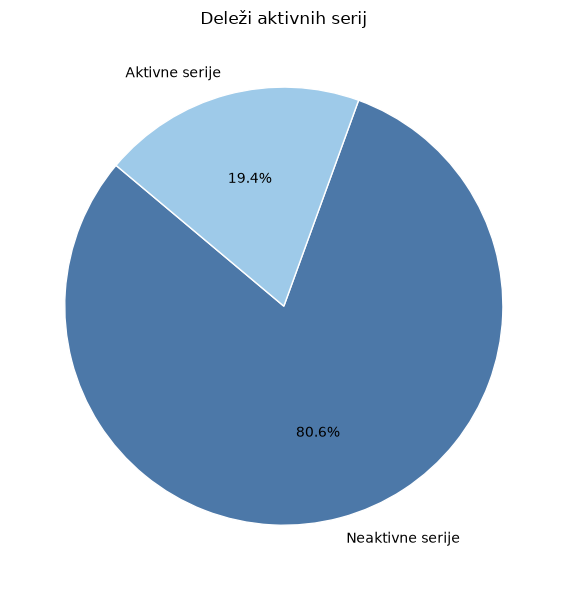

In [286]:
podatki_serije["Najnovejša_epizoda"] = pd.to_datetime(podatki_serije["Najnovejša_epizoda"])
podatki_serije["Aktivna_serija"] = podatki_serije["Najnovejša_epizoda"].dt.year >= 2025
pie_data = podatki_serije["Aktivna_serija"].value_counts()
pie_labels = ["Neaktivne serije", "Aktivne serije"]

colors = ["#4c78a8", "#9ecae9"]

plt.figure(figsize=(6, 6))
plt.pie(
    pie_data,
    labels=pie_labels,
    autopct="%1.1f%%",
    startangle=140,
    textprops={"fontsize": 10},
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
    colors=colors,
)
plt.title("Deleži aktivnih serij")
plt.tight_layout()
plt.show()
